<a href="https://colab.research.google.com/github/RAUNAKTARAFDER123/debugged_health_tool.html/blob/main/RUMEN_OF_COW_METAGENOME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting and reading from zip: 87_ eggNOG Mapper on collection 79_ annotations (1).zip
Processing internal file: eggNOG Mapper on collection 79: annotations/SRR5947932.tabular
Successfully loaded 1323 annotated genes.
Available columns: ['query', 'seed_ortholog', 'evalue', 'score', 'eggNOG_OGs', 'max_annot_lvl', 'COG_category', 'Description', 'Preferred_name', 'GOs', 'EC', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_Module', 'KEGG_Reaction', 'KEGG_rclass', 'BRITE', 'KEGG_TC', 'CAZy', 'BiGG_Reaction', 'PFAMs']


/tmp/ipykernel_2204/472082641.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cog_counts.values, y=cog_counts.index, palette="viridis")


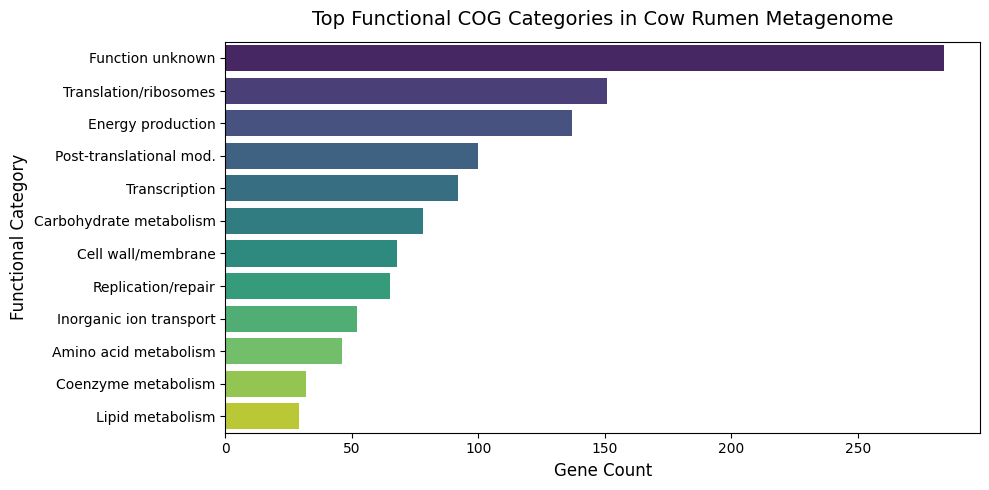

/tmp/ipykernel_2204/472082641.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cazy_counts.values, y=cazy_counts.index, palette="mako")


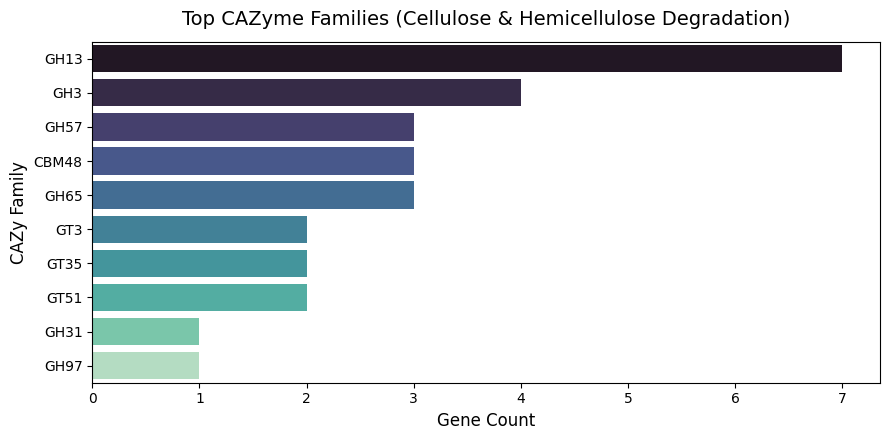

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import glob
import io

# 1. Locate the file (zip or tsv)
zip_files = glob.glob("*.zip")
tsv_files = glob.glob("*annotations*.tsv") or glob.glob("*.tsv")

if zip_files:
    archive_path = zip_files[0]
    print(f"Extracting and reading from zip: {archive_path}")
    with zipfile.ZipFile(archive_path, 'r') as z:
        # Find the annotation file inside the zip archive
        inner_files = [f for f in z.namelist() if not f.endswith('/')]
        target_file = inner_files[0]
        print(f"Processing internal file: {target_file}")
        raw_bytes = z.read(target_file)
        text_data = raw_bytes.decode('utf-8', errors='replace').splitlines()
else:
    file_path = tsv_files[0]
    print(f"Reading directly from TSV: {file_path}")
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        text_data = f.readlines()

# 2. Extract column headers and data lines
header_line = None
data_lines = []

for line in text_data:
    line_clean = line.strip()
    if not line_clean or line_clean.startswith('##'):
        continue
    if line_clean.startswith('#query') or line_clean.startswith('#'):
        header_line = line_clean.lstrip('#').split('\t')
    else:
        data_lines.append(line_clean)

# Load into DataFrame
df = pd.read_csv(io.StringIO('\n'.join(data_lines)), sep='\t', names=header_line)

print(f"Successfully loaded {len(df)} annotated genes.")
print("Available columns:", [str(col) for col in df.columns if col])

# 3. Plot COG Functional Categories
cog_mapping = {
    'A': 'RNA processing', 'B': 'Chromatin structure', 'C': 'Energy production',
    'D': 'Cell cycle control', 'E': 'Amino acid metabolism', 'F': 'Nucleotide metabolism',
    'G': 'Carbohydrate metabolism', 'H': 'Coenzyme metabolism', 'I': 'Lipid metabolism',
    'J': 'Translation/ribosomes', 'K': 'Transcription', 'L': 'Replication/repair',
    'M': 'Cell wall/membrane', 'N': 'Cell motility', 'O': 'Post-translational mod.',
    'P': 'Inorganic ion transport', 'Q': 'Secondary metabolites', 'S': 'Function unknown'
}

if 'COG_category' in df.columns:
    cog_series = df['COG_category'].dropna().apply(lambda x: list(str(x).strip('-'))).explode()
    cog_series = cog_series[cog_series.isin(cog_mapping.keys())]
    cog_counts = cog_series.map(cog_mapping).value_counts().head(12)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=cog_counts.values, y=cog_counts.index, palette="viridis")
    plt.title("Top Functional COG Categories in Cow Rumen Metagenome", fontsize=14, pad=12)
    plt.xlabel("Gene Count", fontsize=12)
    plt.ylabel("Functional Category", fontsize=12)
    plt.tight_layout()
    plt.savefig("rumen_cog_distribution.png", dpi=300)
    plt.show()

# 4. Plot Top CAZyme Families (Fiber Digestion)
if 'CAZy' in df.columns:
    cazy_series = df['CAZy'].dropna().apply(lambda x: [item for item in str(x).split(',') if item and item != '-']).explode()
    cazy_counts = cazy_series.value_counts().head(10)

    if not cazy_counts.empty:
        plt.figure(figsize=(9, 4.5))
        sns.barplot(x=cazy_counts.values, y=cazy_counts.index, palette="mako")
        plt.title("Top CAZyme Families (Cellulose & Hemicellulose Degradation)", fontsize=14, pad=12)
        plt.xlabel("Gene Count", fontsize=12)
        plt.ylabel("CAZy Family", fontsize=12)
        plt.tight_layout()
        plt.savefig("rumen_cazymes.png", dpi=300)
        plt.show()